# Ch 5 — Passage Abstractness by Annotation Tag

For each binary annotation feature (from `passage-content` v3 + `passage-form` v2),
compute mean ± SEM of passage abstractness (`Abs-Conc.Median.median`) when tag=True vs False.

Pipeline:
1. `joint_feature_matrix()` → boolean feature matrix (passages × tags)
2. `abstraction.passage_scores` → continuous abstractness score per passage
3. Inner join on `(_id, scheme, seq)`
4. Per-feature: mean, SEM, delta, Welch t-test
5. Plotnine dot plots sorted by delta (negative = more abstract when tag is present)

In [1]:
import sys
sys.path.insert(0, '/Users/rj416/github/lltk')
sys.path.insert(0, '/Users/rj416/github/largeliterarymodels')

import numpy as np
import pandas as pd
import scipy.stats as st
import clickhouse_connect
from pathlib import Path
from plotnine import (
    ggplot, aes, geom_point, geom_errorbarh, geom_vline,
    facet_wrap, scale_color_manual, scale_color_gradient2,
    coord_flip, theme_bw, theme, element_text, element_blank, labs,
    scale_x_continuous, annotate,
)

DROPBOX_FIGS = Path.home() / 'Dropbox/Prof/Books/AbsLitHist/book/figures'
DROPBOX_FIGS.mkdir(parents=True, exist_ok=True)

def save_fig(p, name, w=11, h=8):
    path = DROPBOX_FIGS / f'psg_abs_{name}.png'
    p.save(path, width=w, height=h, dpi=150, verbose=False)
    print(f'saved → {path}')
    return p

## 1. Feature matrix

In [2]:
from largeliterarymodels.analysis import joint_feature_matrix

feats = joint_feature_matrix(
    tasks=['passage-content', 'passage-form'],
    task_versions={'passage-content': 3, 'passage-form': 2},
    source_agents={
        'passage-content': 'qwen3.5-35b-a3b',
        'passage-form':    'claude-sonnet-4-6',
    },
)
print(f'Feature matrix: {feats.shape}  index levels: {feats.index.names}')
feats.head(3)

[passage-content] filtered 4638 non-prose passages (6236 kept)


[passage-form] filtered 284 non-prose passages (1402 kept)


Feature matrix: (1304, 94)  index levels: ['_id', 'scheme', 'seq']


content.scene_content:abduction_or_captivity  \
_id                     scheme seq                                                 
_blbooks/1719/002269145 p500   3                                           False   
                               7                                           False   
                               10                                          False   

                                    content.scene_content:ball_or_social_gathering  \
_id                     scheme seq                                                   
_blbooks/1719/002269145 p500   3                                             False   
                               7                                             False   
                               10                                            False   

                                    content.scene_content:battle_or_violence  \
_id                     scheme seq                                             
_blbooks/1719/002269145 p500   3                                       False   
                               7                                       False   
                               10                                      False   

                                    content.scene_content:courtship  \
_id                     scheme seq                                    
_blbooks/1719/002269145 p500   3                              False   
                               7                               True   
                               10                              True   

                                    content.scene_content:deception_or_intrigue  \
_id                     scheme seq                                                
_blbooks/1719/002269145 p500   3                                          False   
                               7                                           True   
                               10                                          True   

                                    content.scene_content:domestic_routine  \
_id                     scheme seq                                           
_blbooks/1719/002269145 p500   3                                     False   
                               7                                     False   
                               10                                    False   

                                    content.scene_content:feast_or_meal  \
_id                     scheme seq                                        
_blbooks/1719/002269145 p500   3                                  False   
                               7                                  False   
                               10                                 False   

                                    content.scene_content:illness_or_death  \
_id                     scheme seq                                           
_blbooks/1719/002269145 p500   3                                     False   
                               7                                     False   
                               10                                    False   

                                    content.scene_content:legal_or_financial  \
_id                     scheme seq                                             
_blbooks/1719/002269145 p500   3                                       False   
                               7                                       False   
                               10                                      False   

                                    content.scene_content:moral_reflection  \
_id                     scheme seq                                           
_blbooks/1719/002269145 p500   3                                     False   
                               7                                     False   
                               10                                    False   

                                    ...  form.physicality_lev

## 2. Passage abstractness scores from CH

In [3]:
client = clickhouse_connect.get_client(
    host='localhost', port=8123, username='lltk', password='lltk'
)

scores_df = client.query_df("""
    SELECT _id, scheme, seq,
           scores['Abs-Conc.Median.median']  AS score_median,
           scores['Abs-Conc.Median.orig']    AS score_orig,
           scores['Abs-Conc.MT-Conc.orig']   AS score_mt
    FROM abstraction.passage_scores
    WHERE lang = 'en'
      AND mapContains(scores, 'Abs-Conc.Median.median')
""").set_index(['_id', 'scheme', 'seq'])

print(f'{len(scores_df):,} scored passages')
scores_df.describe()

239,109 scored passages


,score_median,score_orig,score_mt
count,239109.000000,239109.000000,239109.000000
mean,-0.467637,-0.041620,0.012625
std,0.323822,0.216416,0.283186
min,-1.686759,-1.150649,-1.267076
25%,-0.707661,-0.199725,-0.196098
50%,-0.503891,-0.068890,-0.021243
75%,-0.256930,0.092610,0.191070
max,1.246712,1.345622,1.769889


## 3. Join

In [4]:
joined = feats.join(scores_df[['score_median']], how='inner')
print(f'Joined: {len(joined):,} passages × {feats.shape[1]} features')

# score_median: negative = abstract, positive = concrete
# negate so that higher = more abstract (easier to read)
joined['abstractness'] = -joined['score_median']
print(f'abstractness mean={joined["abstractness"].mean():.3f}  std={joined["abstractness"].std():.3f}')

Joined: 1,304 passages × 94 features
abstractness mean=0.438  std=0.333


## 4. Per-feature stats

In [5]:
rows = []
for feat in feats.columns:
    mask = joined[feat].astype(bool)
    s_t = joined.loc[mask, 'abstractness'].dropna()
    s_f = joined.loc[~mask, 'abstractness'].dropna()
    if min(len(s_t), len(s_f)) < 30:
        continue
    t_stat, p = st.ttest_ind(s_t, s_f, equal_var=False)
    rows.append({
        'feature':    feat,
        'n_true':     len(s_t),
        'n_false':    len(s_f),
        'mean_true':  s_t.mean(),
        'sem_true':   s_t.sem(),
        'mean_false': s_f.mean(),
        'sem_false':  s_f.sem(),
        'delta':      s_t.mean() - s_f.mean(),
        'p':          p,
    })

stats = pd.DataFrame(rows).sort_values('delta', ascending=False)
stats['q'] = stats['p'].rank() / len(stats) * stats['p']  # BH approx
stats['sig'] = stats['p'] < 0.001
stats['task'] = stats['feature'].str.split('.').str[0]
stats['field'] = stats['feature'].str.split('.').str[1]
stats['label'] = stats['feature'].str.split('.').str[1:].str.join('.')

print(f'{len(stats)} features with n≥30')
print(f'  sig p<0.001: {stats["sig"].sum()}')
stats.head(10)[['feature','n_true','mean_true','mean_false','delta','p']]

77 features with n≥30
  sig p<0.001: 46


,feature,n_true,mean_true,mean_false,delta,p
76,form.uses_nominalization,1048,0.523684,0.085257,0.438427,1.041628e-71
66,form.physicality_level:absent,85,0.820414,0.410920,0.409494,3.954179e-28
73,form.abstractions_as_agents,812,0.555376,0.243255,0.312122,1.830321e-59
36,form.narration_modes:epistolary,39,0.716053,0.429028,0.287024,2.143444e-10
35,form.narration_modes:embedded_letter,55,0.668420,0.427449,0.240971,4.339578e-10
39,form.interiority_focus:free_indirect_or_monologue,158,0.616154,0.412997,0.203157,2.770444e-16
51,form.distance_traveled:0,450,0.565230,0.370367,0.194863,5.414722e-23
67,form.physicality_level:incidental,972,0.483821,0.302328,0.181494,5.411045e-13
27,content.threats:psychological_or_emotional,366,0.560922,0.389499,0.171423,2.090354e-18
74,form.characters_known_by_reputation,766,0.504015,0.343070,0.160944,1.380092e-17


## 5. Panel A — All features ranked by delta

saved → /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/psg_abs_all_features.png


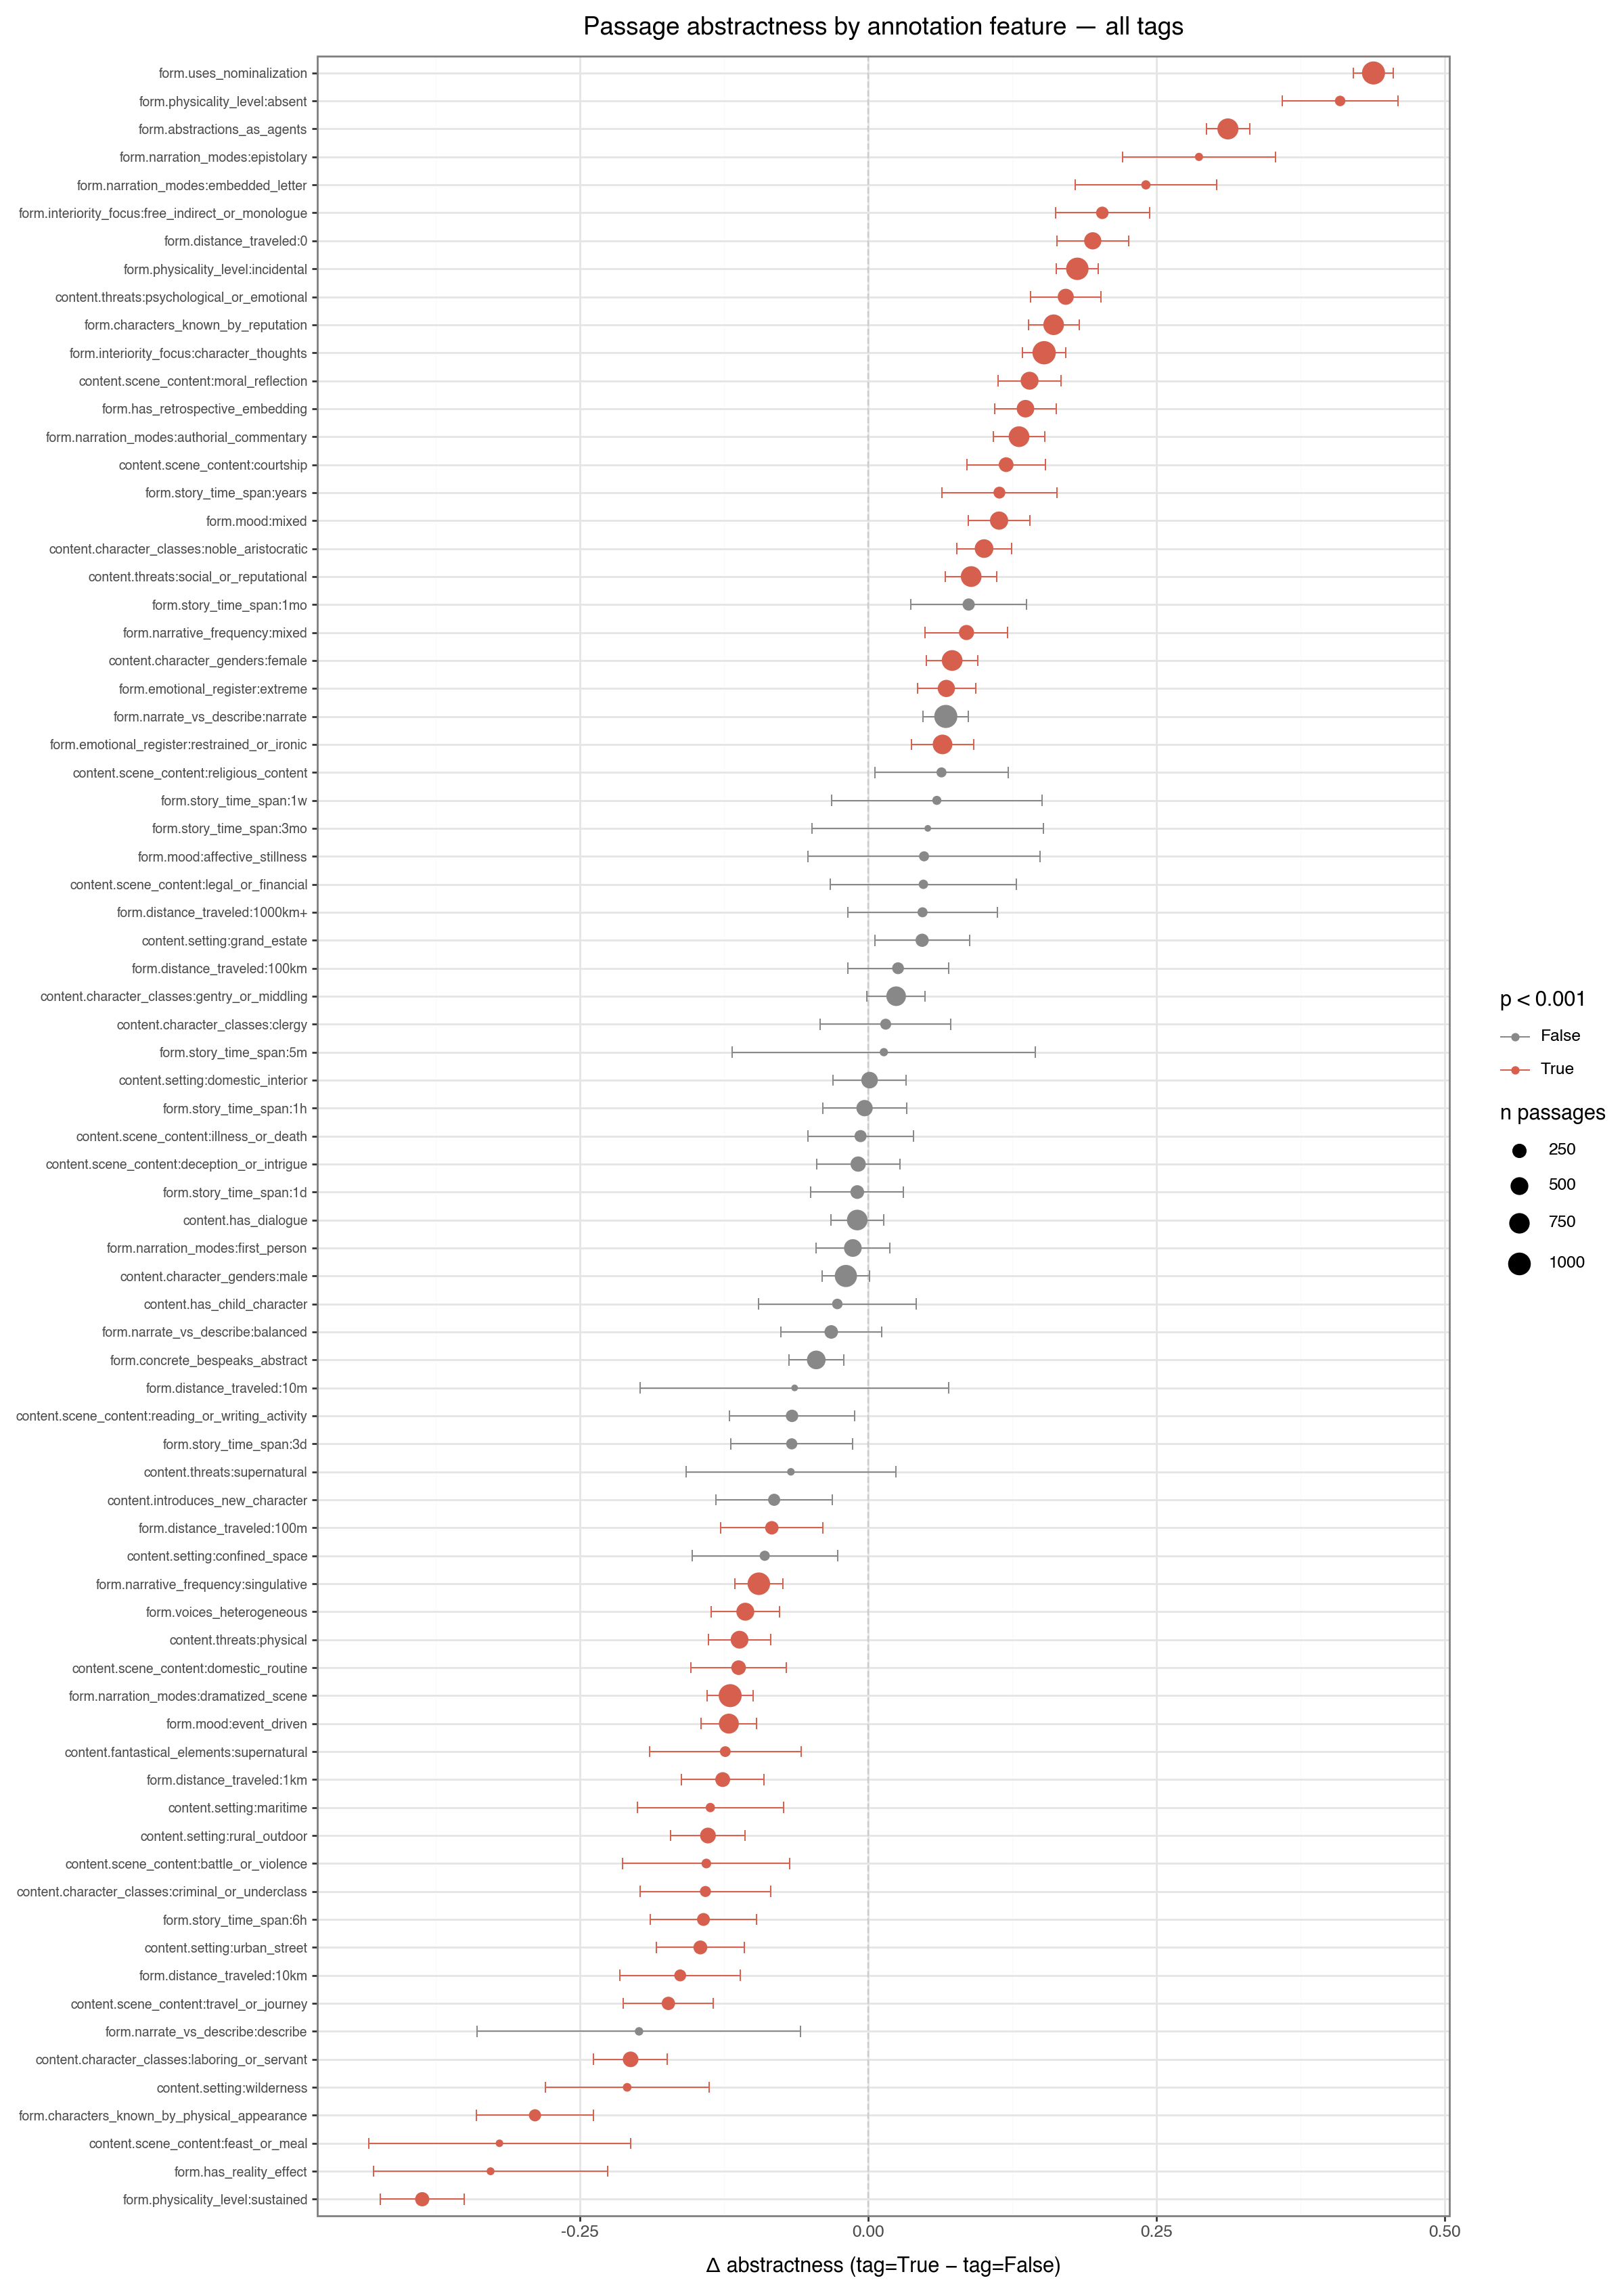

In [6]:
plot_df = stats.copy()
plot_df['feature'] = pd.Categorical(plot_df['feature'],
                                     categories=plot_df.sort_values('delta')['feature'],
                                     ordered=True)

p = (
    ggplot(plot_df, aes(x='delta', y='feature', color='sig', size='n_true'))
    + geom_vline(xintercept=0, linetype='dashed', color='#cccccc')
    + geom_errorbarh(
        aes(xmin='delta - sem_true * 1.96', xmax='delta + sem_true * 1.96'),
        height=0.4, size=0.4
    )
    + geom_point()
    + scale_color_manual(values={True: '#d6604d', False: '#888888'})
    + labs(
        x='Δ abstractness (tag=True − tag=False)',
        y='', color='p < 0.001', size='n passages',
        title='Passage abstractness by annotation feature — all tags'
    )
    + theme_bw()
    + theme(
        figure_size=(12, max(8, len(plot_df) * 0.22)),
        axis_text_y=element_text(size=7),
    )
)
save_fig(p, 'all_features', w=12, h=max(8, len(plot_df) * 0.22))

## 6. Panel B — content v3 character_classes (class gradient)

saved → /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/psg_abs_class_gradient.png


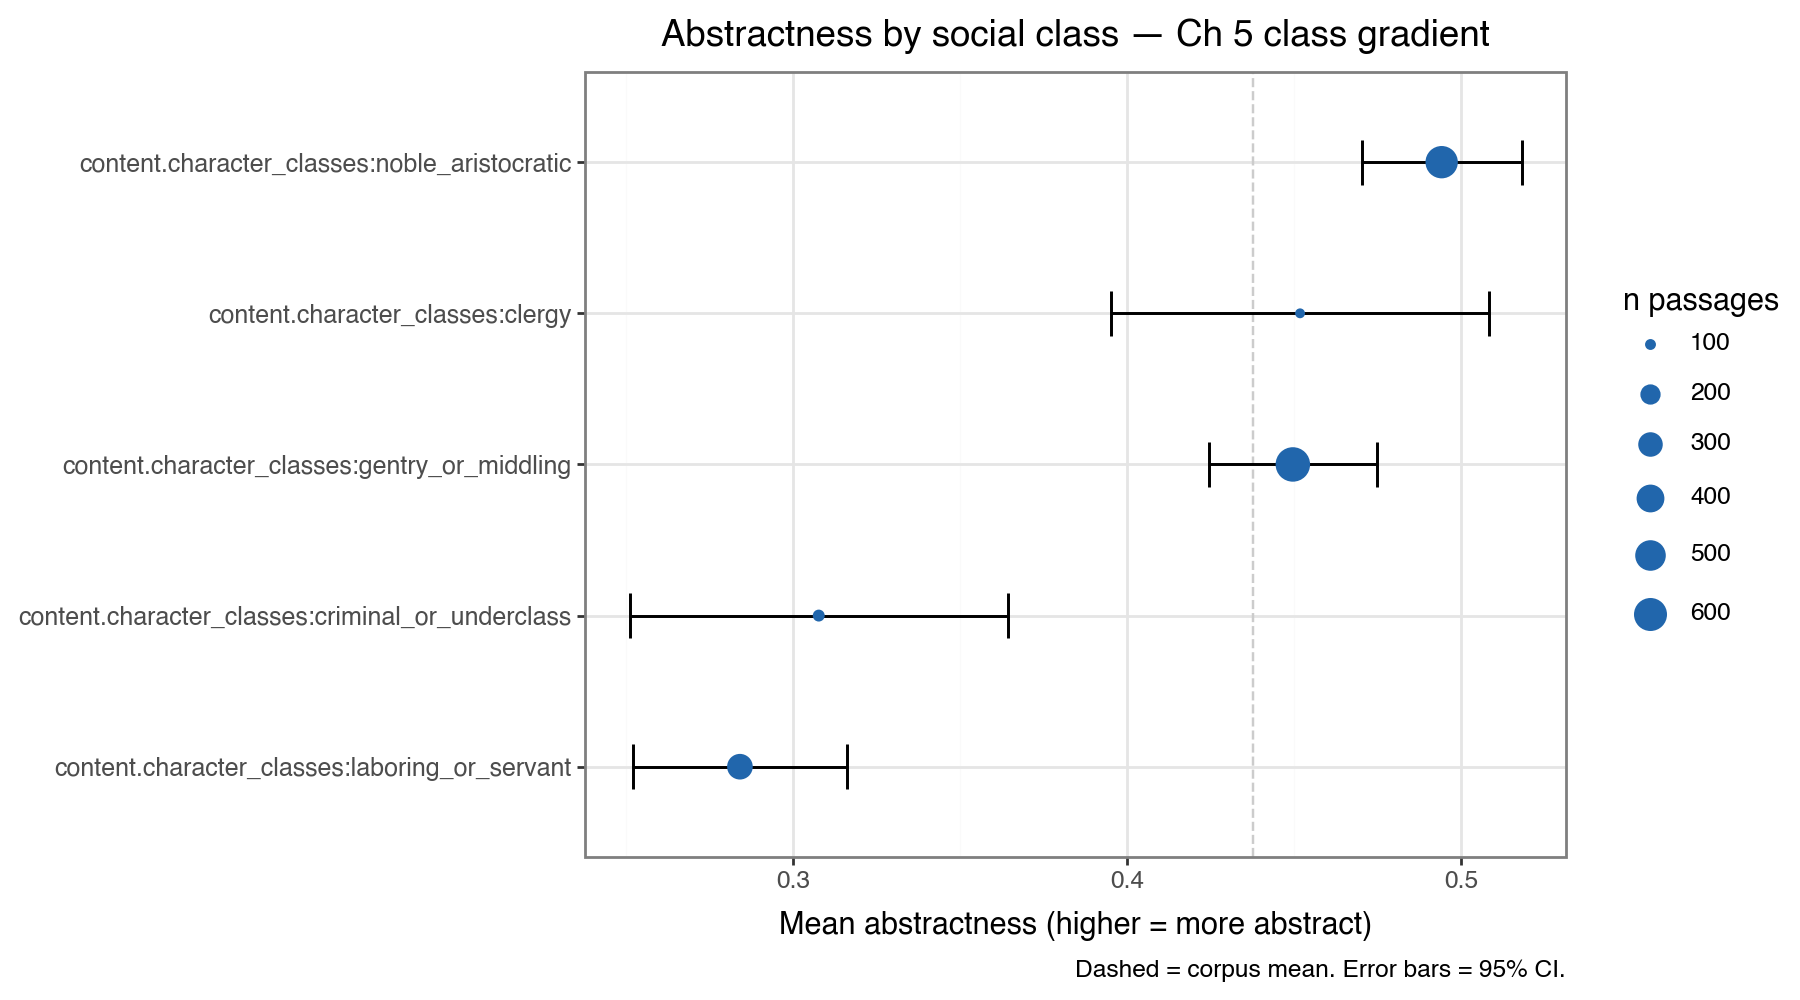

In [7]:
class_feats = stats[stats['feature'].str.contains('character_class|laboring|noble|gentry|clergy|criminal')].copy()
class_feats['feature'] = pd.Categorical(
    class_feats['feature'],
    categories=class_feats.sort_values('mean_true')['feature'],
    ordered=True
)

p = (
    ggplot(class_feats, aes(x='mean_true', y='feature'))
    + geom_vline(xintercept=joined['abstractness'].mean(),
                 linetype='dashed', color='#cccccc')
    + geom_errorbarh(
        aes(xmin='mean_true - sem_true * 1.96', xmax='mean_true + sem_true * 1.96'),
        height=0.3, size=0.6
    )
    + geom_point(aes(size='n_true'), color='#2166ac')
    + labs(
        x='Mean abstractness (higher = more abstract)', y='',
        size='n passages',
        title='Abstractness by social class — Ch 5 class gradient',
        caption='Dashed = corpus mean. Error bars = 95% CI.'
    )
    + theme_bw()
    + theme(figure_size=(9, 5), axis_text_y=element_text(size=9))
)
save_fig(p, 'class_gradient', w=9, h=5)

## 7. Panel C — form features (allegorical regime, physicality, narration)

saved → /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/psg_abs_form_features.png


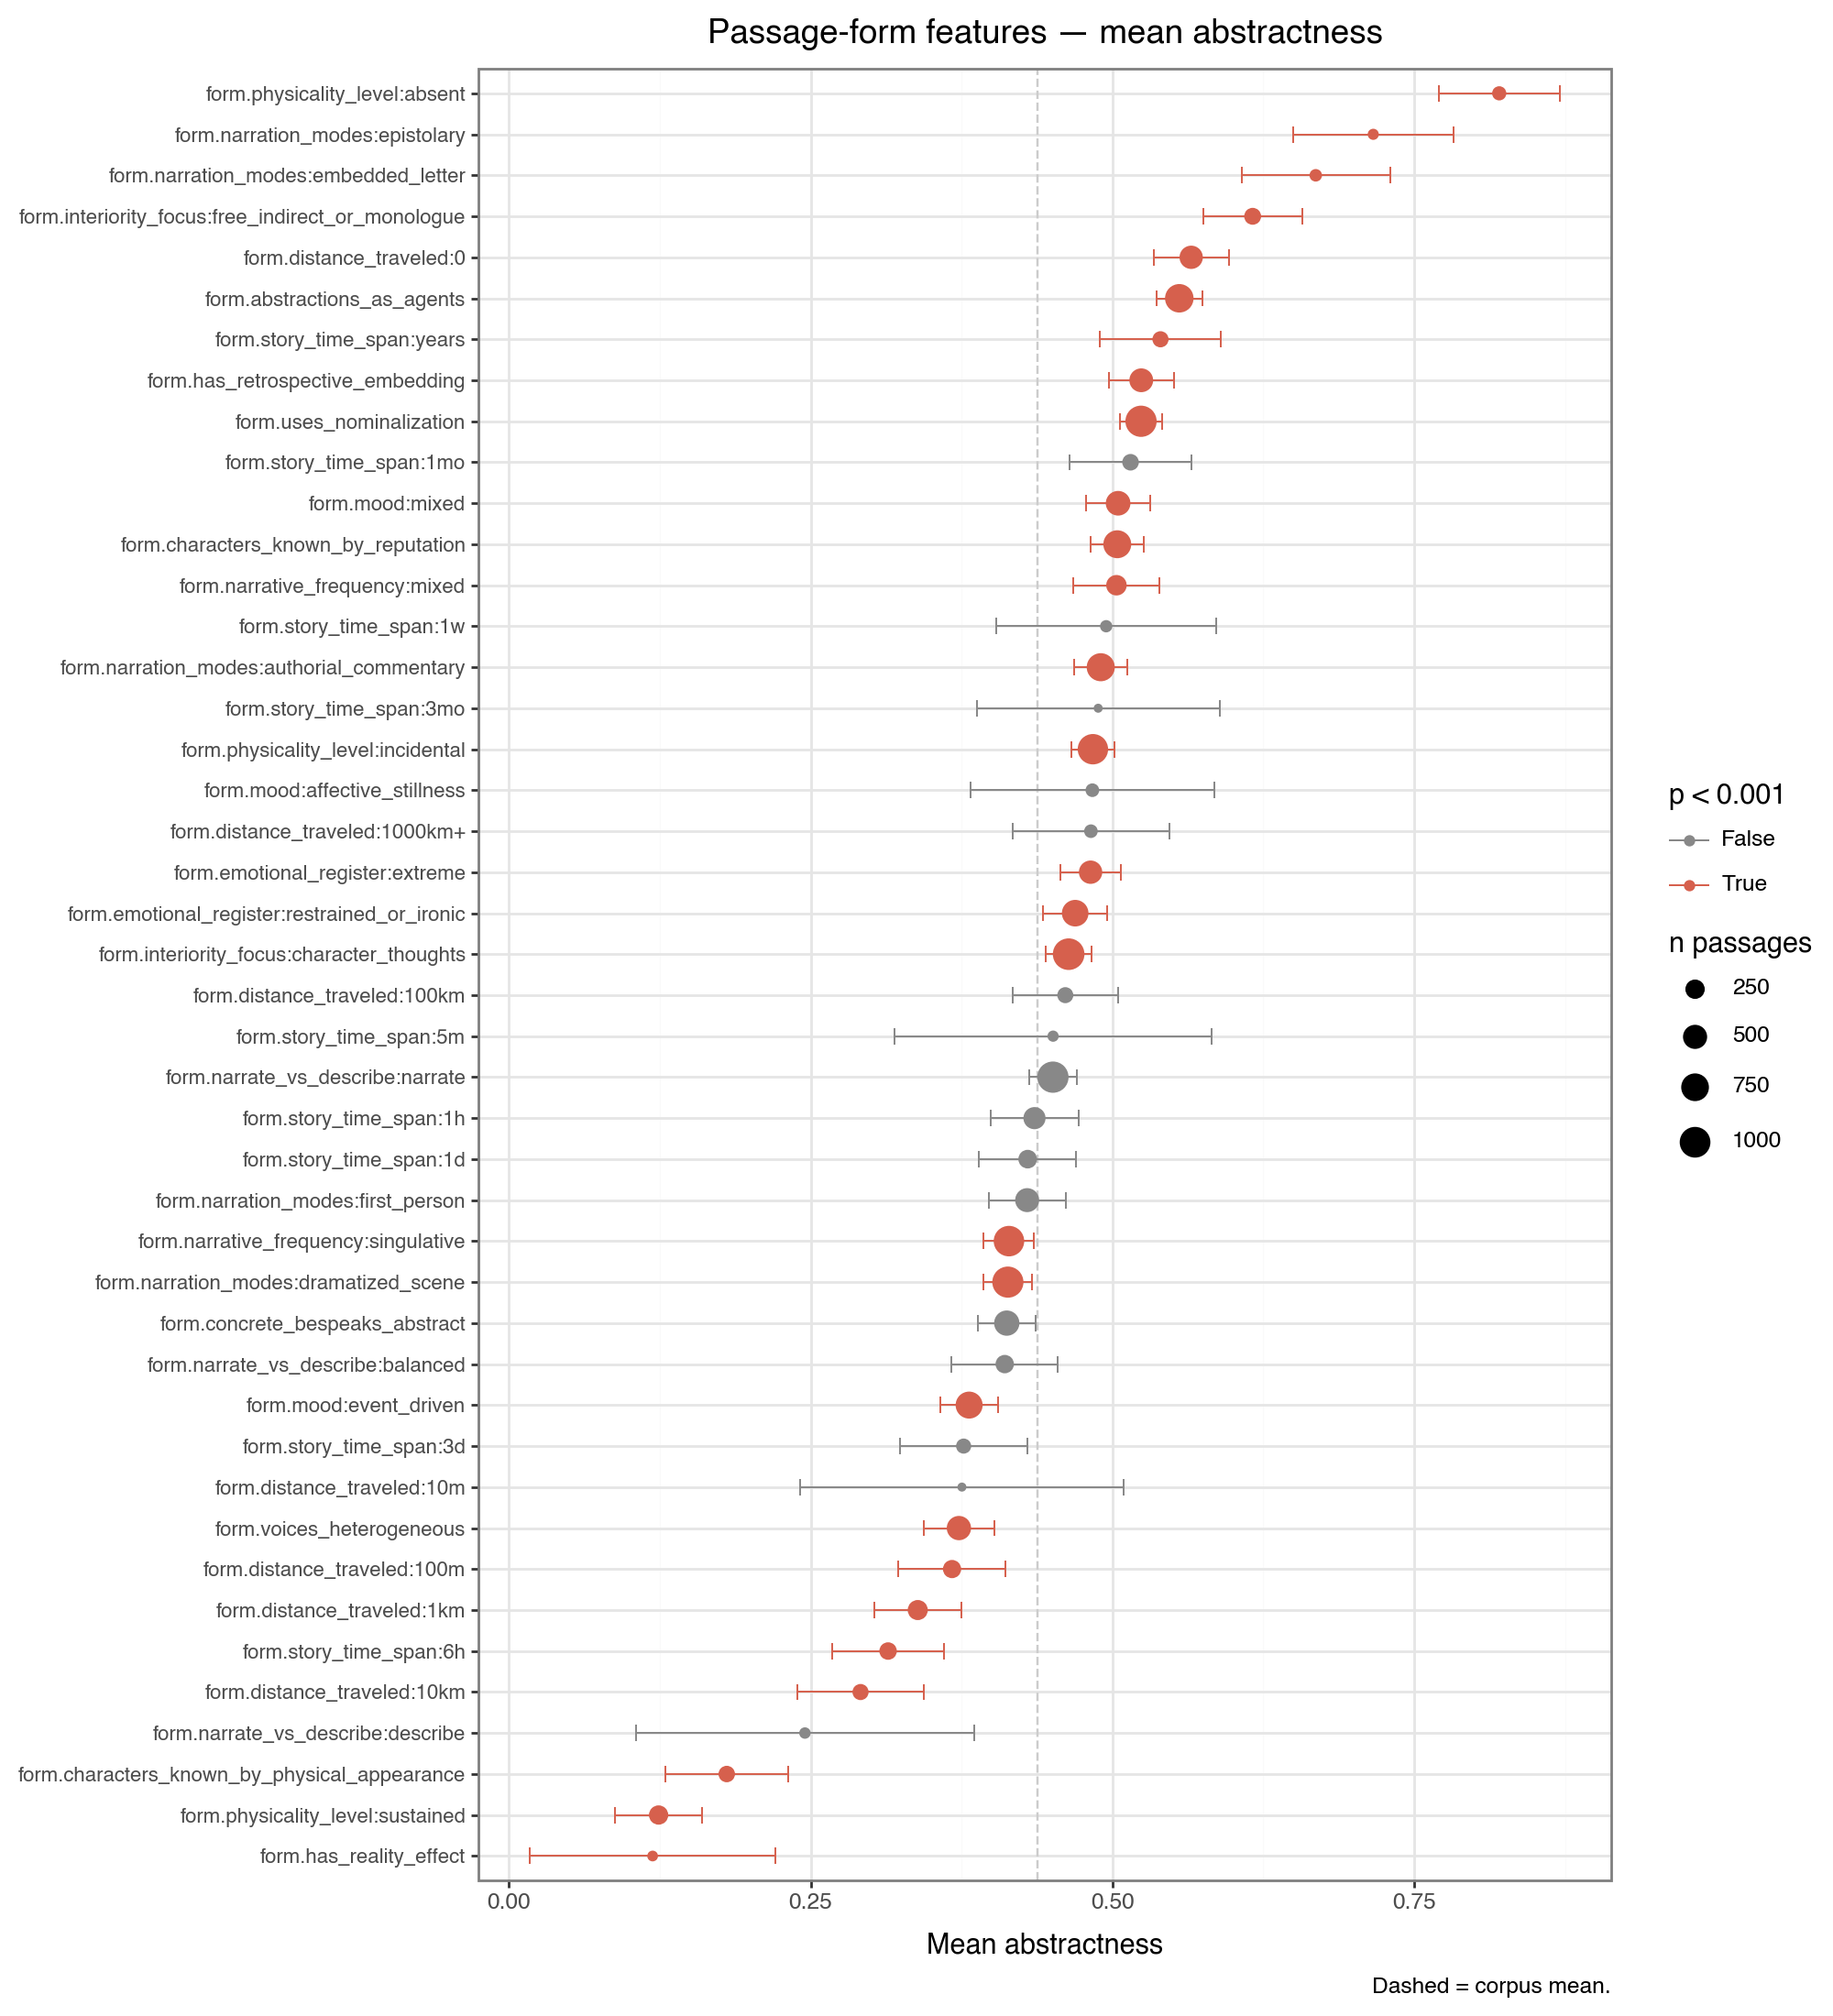

In [8]:
# passage-form fields as mean abstractness (not delta — show absolute level)
# For ordinal/categorical fields: physicality_level, emotional_register, narration_modes

form_feats = stats[stats['task'] == 'form'].copy()
form_feats = form_feats[~form_feats['field'].isin(['confidence','notes','is_prose_fiction'])]
form_feats['feature'] = pd.Categorical(
    form_feats['feature'],
    categories=form_feats.sort_values('mean_true')['feature'],
    ordered=True
)

p = (
    ggplot(form_feats, aes(x='mean_true', y='feature', color='sig'))
    + geom_vline(xintercept=joined['abstractness'].mean(),
                 linetype='dashed', color='#cccccc')
    + geom_errorbarh(
        aes(xmin='mean_true - sem_true * 1.96', xmax='mean_true + sem_true * 1.96'),
        height=0.4, size=0.4
    )
    + geom_point(aes(size='n_true'))
    + scale_color_manual(values={True: '#d6604d', False: '#888888'})
    + labs(
        x='Mean abstractness', y='', color='p < 0.001', size='n passages',
        title='Passage-form features — mean abstractness',
        caption='Dashed = corpus mean.'
    )
    + theme_bw()
    + theme(
        figure_size=(10, max(6, len(form_feats) * 0.25)),
        axis_text_y=element_text(size=8)
    )
)
save_fig(p, 'form_features', w=10, h=max(6, len(form_feats) * 0.25))

## 8. Panel D — scene content (top/bottom 15 by delta)

saved → /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/psg_abs_scene_content.png


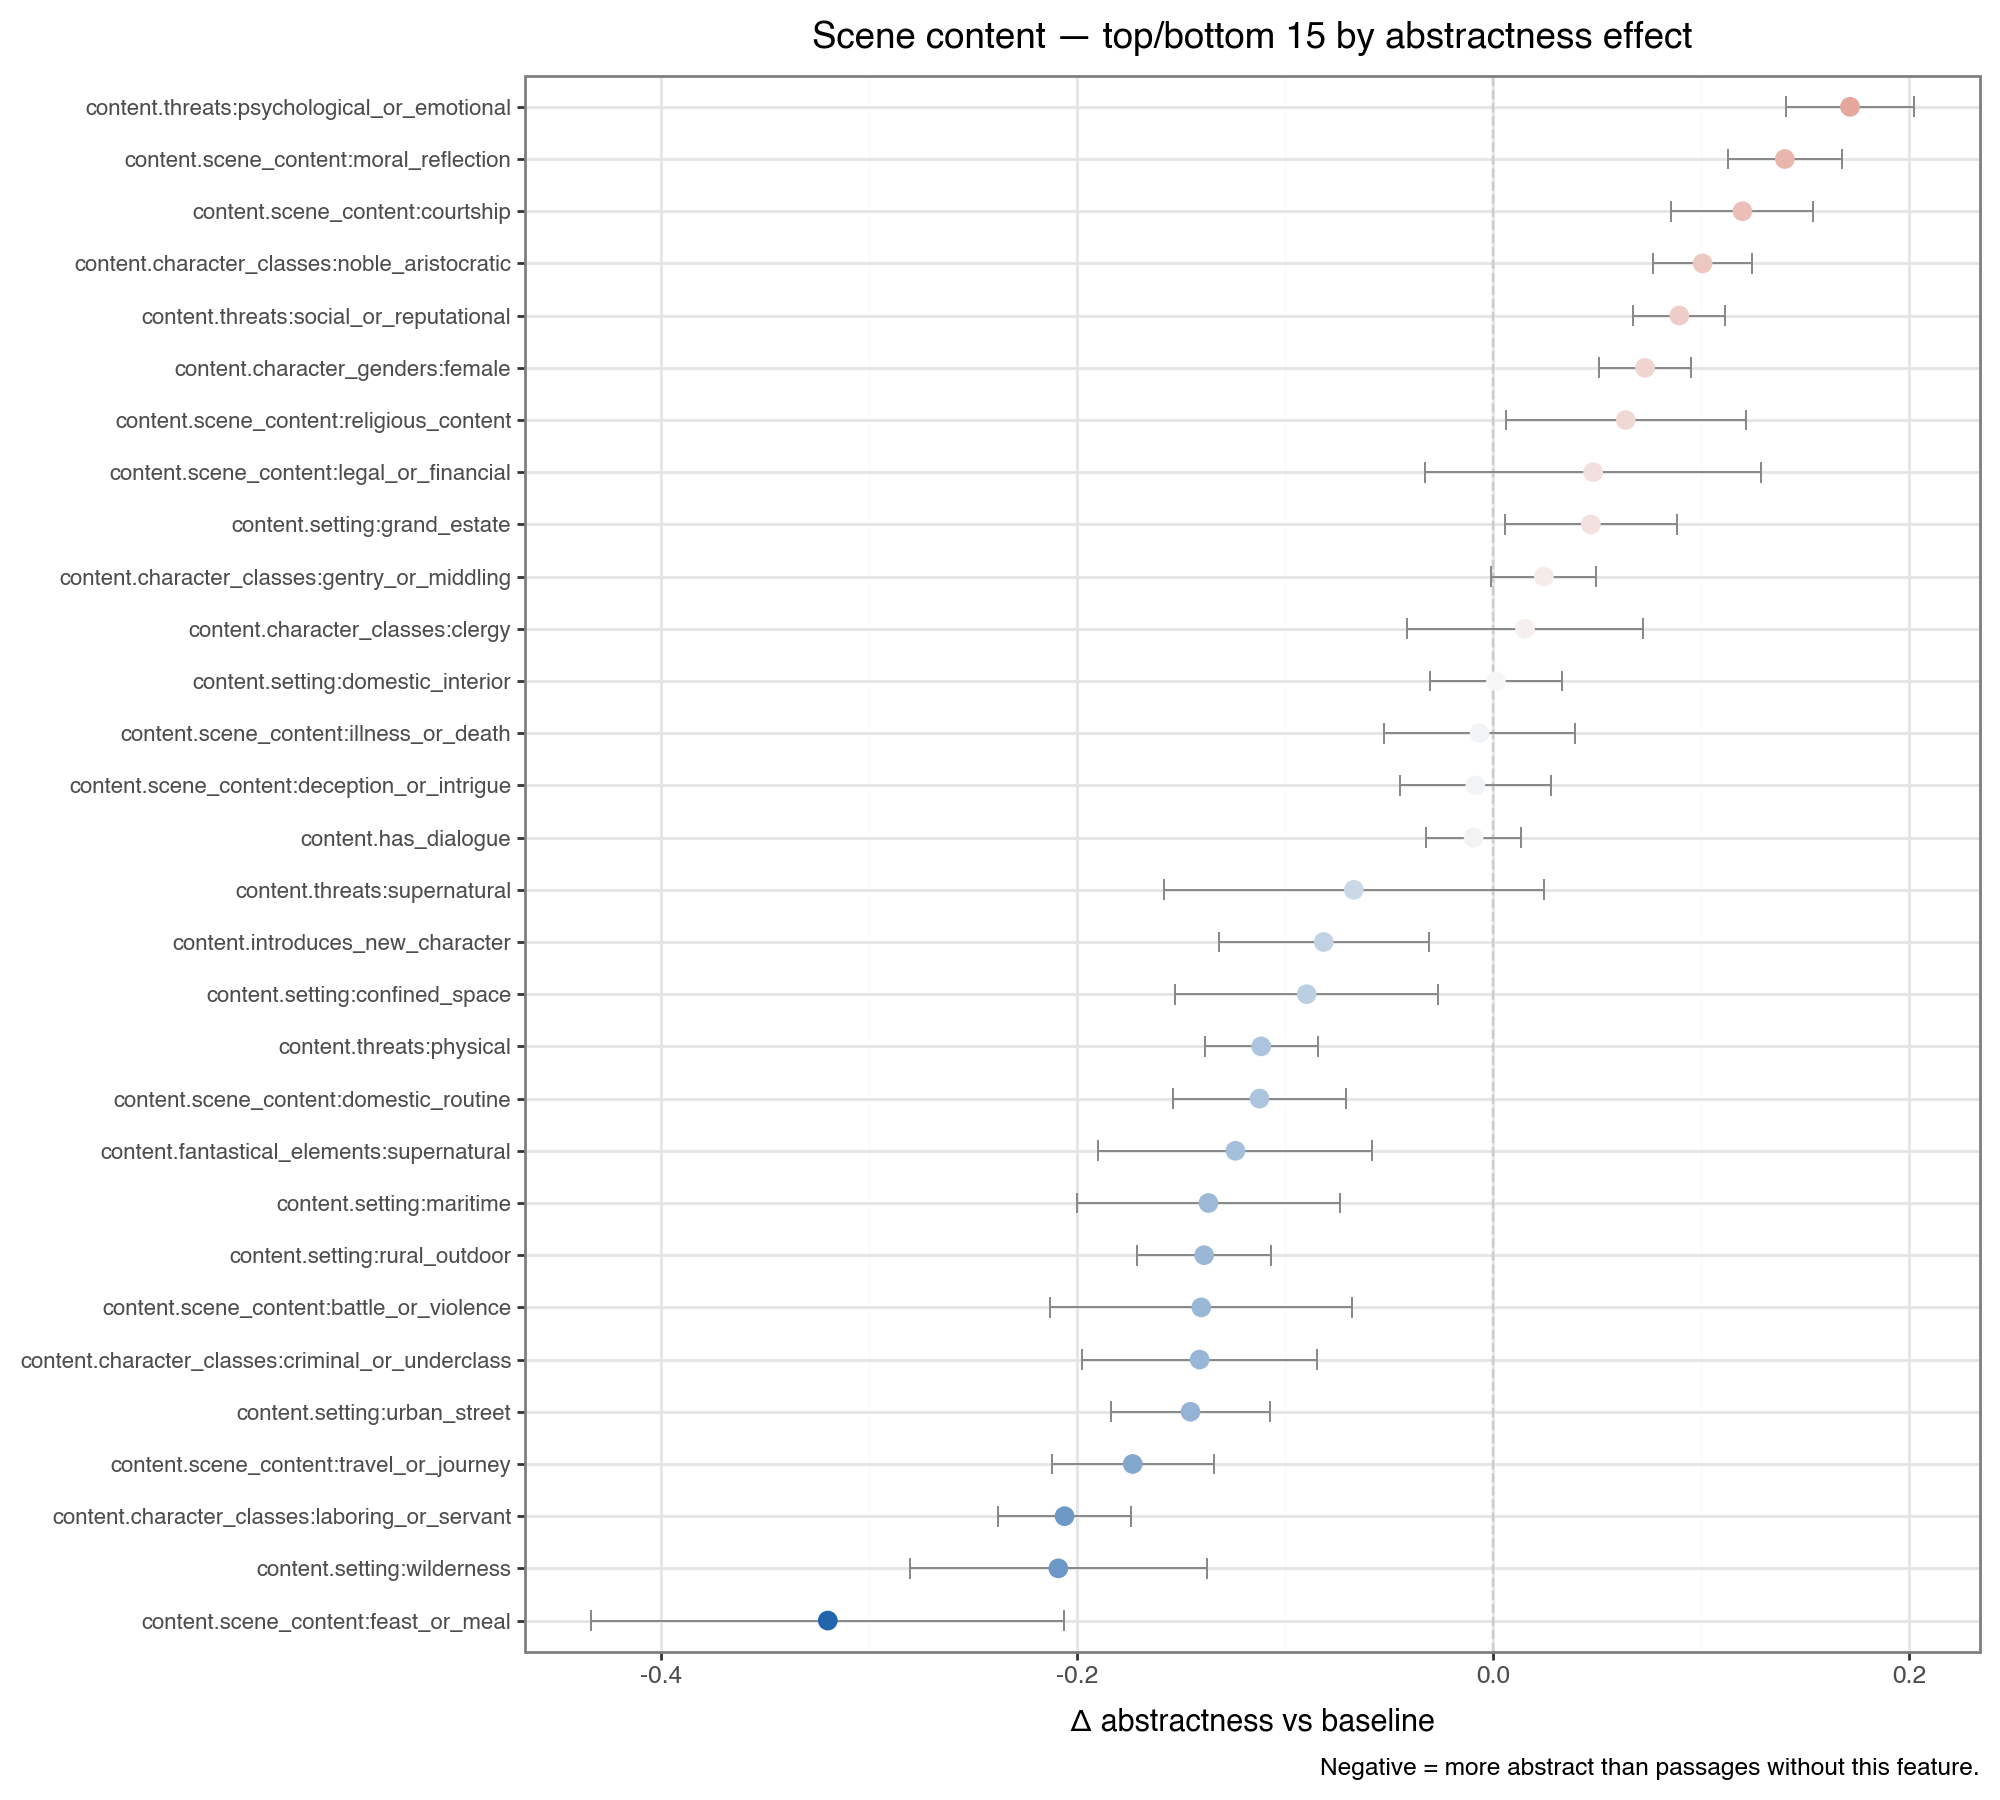

In [9]:
content_feats = stats[
    (stats['task'] == 'content')
    & ~stats['field'].isin(['confidence','notes','is_prose_fiction','character_classes'])
].copy()

# Top 15 most abstract + bottom 15 most concrete
top = pd.concat([
    content_feats.nsmallest(15, 'delta'),  # most abstract (negative delta = more abstract than baseline)
    content_feats.nlargest(15, 'delta'),
]).drop_duplicates('feature')

top['feature'] = pd.Categorical(
    top['feature'],
    categories=top.sort_values('delta')['feature'],
    ordered=True
)

p = (
    ggplot(top, aes(x='delta', y='feature', color='delta'))
    + geom_vline(xintercept=0, linetype='dashed', color='#cccccc')
    + geom_errorbarh(
        aes(xmin='delta - sem_true * 1.96', xmax='delta + sem_true * 1.96'),
        height=0.4, size=0.4, color='#888888'
    )
    + geom_point(size=3)
    + scale_color_gradient2(
        low='#2166ac', mid='#f7f7f7', high='#d6604d', midpoint=0
    )
    + labs(
        x='Δ abstractness vs baseline', y='',
        title='Scene content — top/bottom 15 by abstractness effect',
        caption='Negative = more abstract than passages without this feature.'
    )
    + theme_bw()
    + theme(figure_size=(10, 9), axis_text_y=element_text(size=8), legend_position='none')
)
save_fig(p, 'scene_content', w=10, h=9)

## 9. Summary table

In [10]:
print('Most ABSTRACT features (tag=True → more abstract):')
print(stats.nsmallest(20, 'delta')[
    ['feature','n_true','mean_true','mean_false','delta','p']
].to_string(index=False))

print('\nMost CONCRETE features (tag=True → more concrete):')
print(stats.nlargest(20, 'delta')[
    ['feature','n_true','mean_true','mean_false','delta','p']
].to_string(index=False))

Most ABSTRACT features (tag=True → more abstract):
                                         feature  n_true  mean_true  mean_false     delta            p
                form.physicality_level:sustained     247   0.124039    0.510889 -0.386850 7.247157e-56
                         form.has_reality_effect      36   0.119095    0.446656 -0.327561 3.051699e-07
             content.scene_content:feast_or_meal      33   0.125865    0.445707 -0.319842 4.633255e-06
    form.characters_known_by_physical_appearance     144   0.180491    0.469531 -0.289041 1.871685e-20
                      content.setting:wilderness      45   0.235776    0.444827 -0.209051 1.007593e-06
   content.character_classes:laboring_or_servant     332   0.284009    0.490078 -0.206069 3.024531e-24
               form.narrate_vs_describe:describe      42   0.245262    0.444014 -0.198752 8.618059e-03
         content.scene_content:travel_or_journey     201   0.291017    0.464327 -0.173310 1.037993e-13
                     f